In [1]:
from spec import *

In [ ]:
### Simple 3 clouds
runnerName = 'DIplanets_test_gravity'
mode = 'simple'
# mode = 'complex'
gases = ['Fe', 'Al2O3', 'MgSiO3', 'Mg2SiO4', 'MnS', 'Na2S'] 
n_levels = 1

if mode == 'simple':
    # ── Option A: simple (replaces the manual sorted(set(...)) block) ──────────
    fsed_list = generate_fsed(
        mode='simple',
        start=1.20,
        stop=1.50,  # exclusive – last value will be 1.19
        total=n_levels,   # number of values to generate)
    )
    # → [1.0, 1.01, 1.02, ..., 1.19]

elif mode == 'complex':
    # ── Option B: complex (per-species, mixed direction) ───────────────────────
    iterationName = "complex_fsed_test_fe[14]_mgsiO3[3.1-3.9]_na2s[4.6-2.8]"
    runnerName = f"{runnerName}_{iterationName}"

    fsed_list = generate_fsed(
        mode='complex',
        species_params={
            'Fe':     14,                            # constant
            'MgSiO3': {'start': 3.1, 'stop': 3.9},  # increasing
            'Na2S':   {'start': 4.6, 'stop': 2.8},  # decreasing
        },
        n_steps=n_levels,
        gases=gases,   # enables mismatch validation
    )
    # → [{'Fe': 14, 'MgSiO3': 3.1, 'Na2S': 4.6}, ..., {'Fe': 14, 'MgSiO3': 3.9, 'Na2S': 2.8}]

param_grid = create_parameter_grid(
    Teff_list=[1600], # K 
    C_to_O_list=[0.], # C/O ratio
    wave_range_list=[[1., 10.]], # wavelength range in microns for the output spectrum
    R_list=[700], # Spectral resolution for regridding the output spectrum
    gravity_list=[1000, 2000, 5000, 10000, 20000, 50000], # gravity in unit of cm/s^2
    fsed_list=fsed_list, # the range of fsed values to run (either in simple mode (same or all gases) or complex mode (per-species))
    excluded_mol_list=['CH4'], # gas to exclude from the atmosphere (e.g. to test its impact on the spectrum)
    gases_list=[gases],
    kzz_list=[1e7],
    cloudfree=False  # Set to True for cloud-free models only
)

print(f"Total models to run: {len(param_grid)}")

# Run the grid
results, output_dir = run_parallel_grid(
    param_grid, 
    runname=runnerName,  # Creates directory like "bd_grid_20241016_143022"
    n_processes=4  # Adjust based on your CPU
)

Total models to run: 6
Output directory: DIplanets_test_gravity_20260429_205105
Running 6 models on 4 processes...
CPU count: 8
Starting parallel pool...
All models completed, writing config file...
Configuration written to DIplanets_test_gravity_20260429_205105/config.txt

Results saved to DIplanets_test_gravity_20260429_205105
Configuration saved to DIplanets_test_gravity_20260429_205105/config.txt
Completed: 6/6 models successful
Total time: 0:01:06.134475


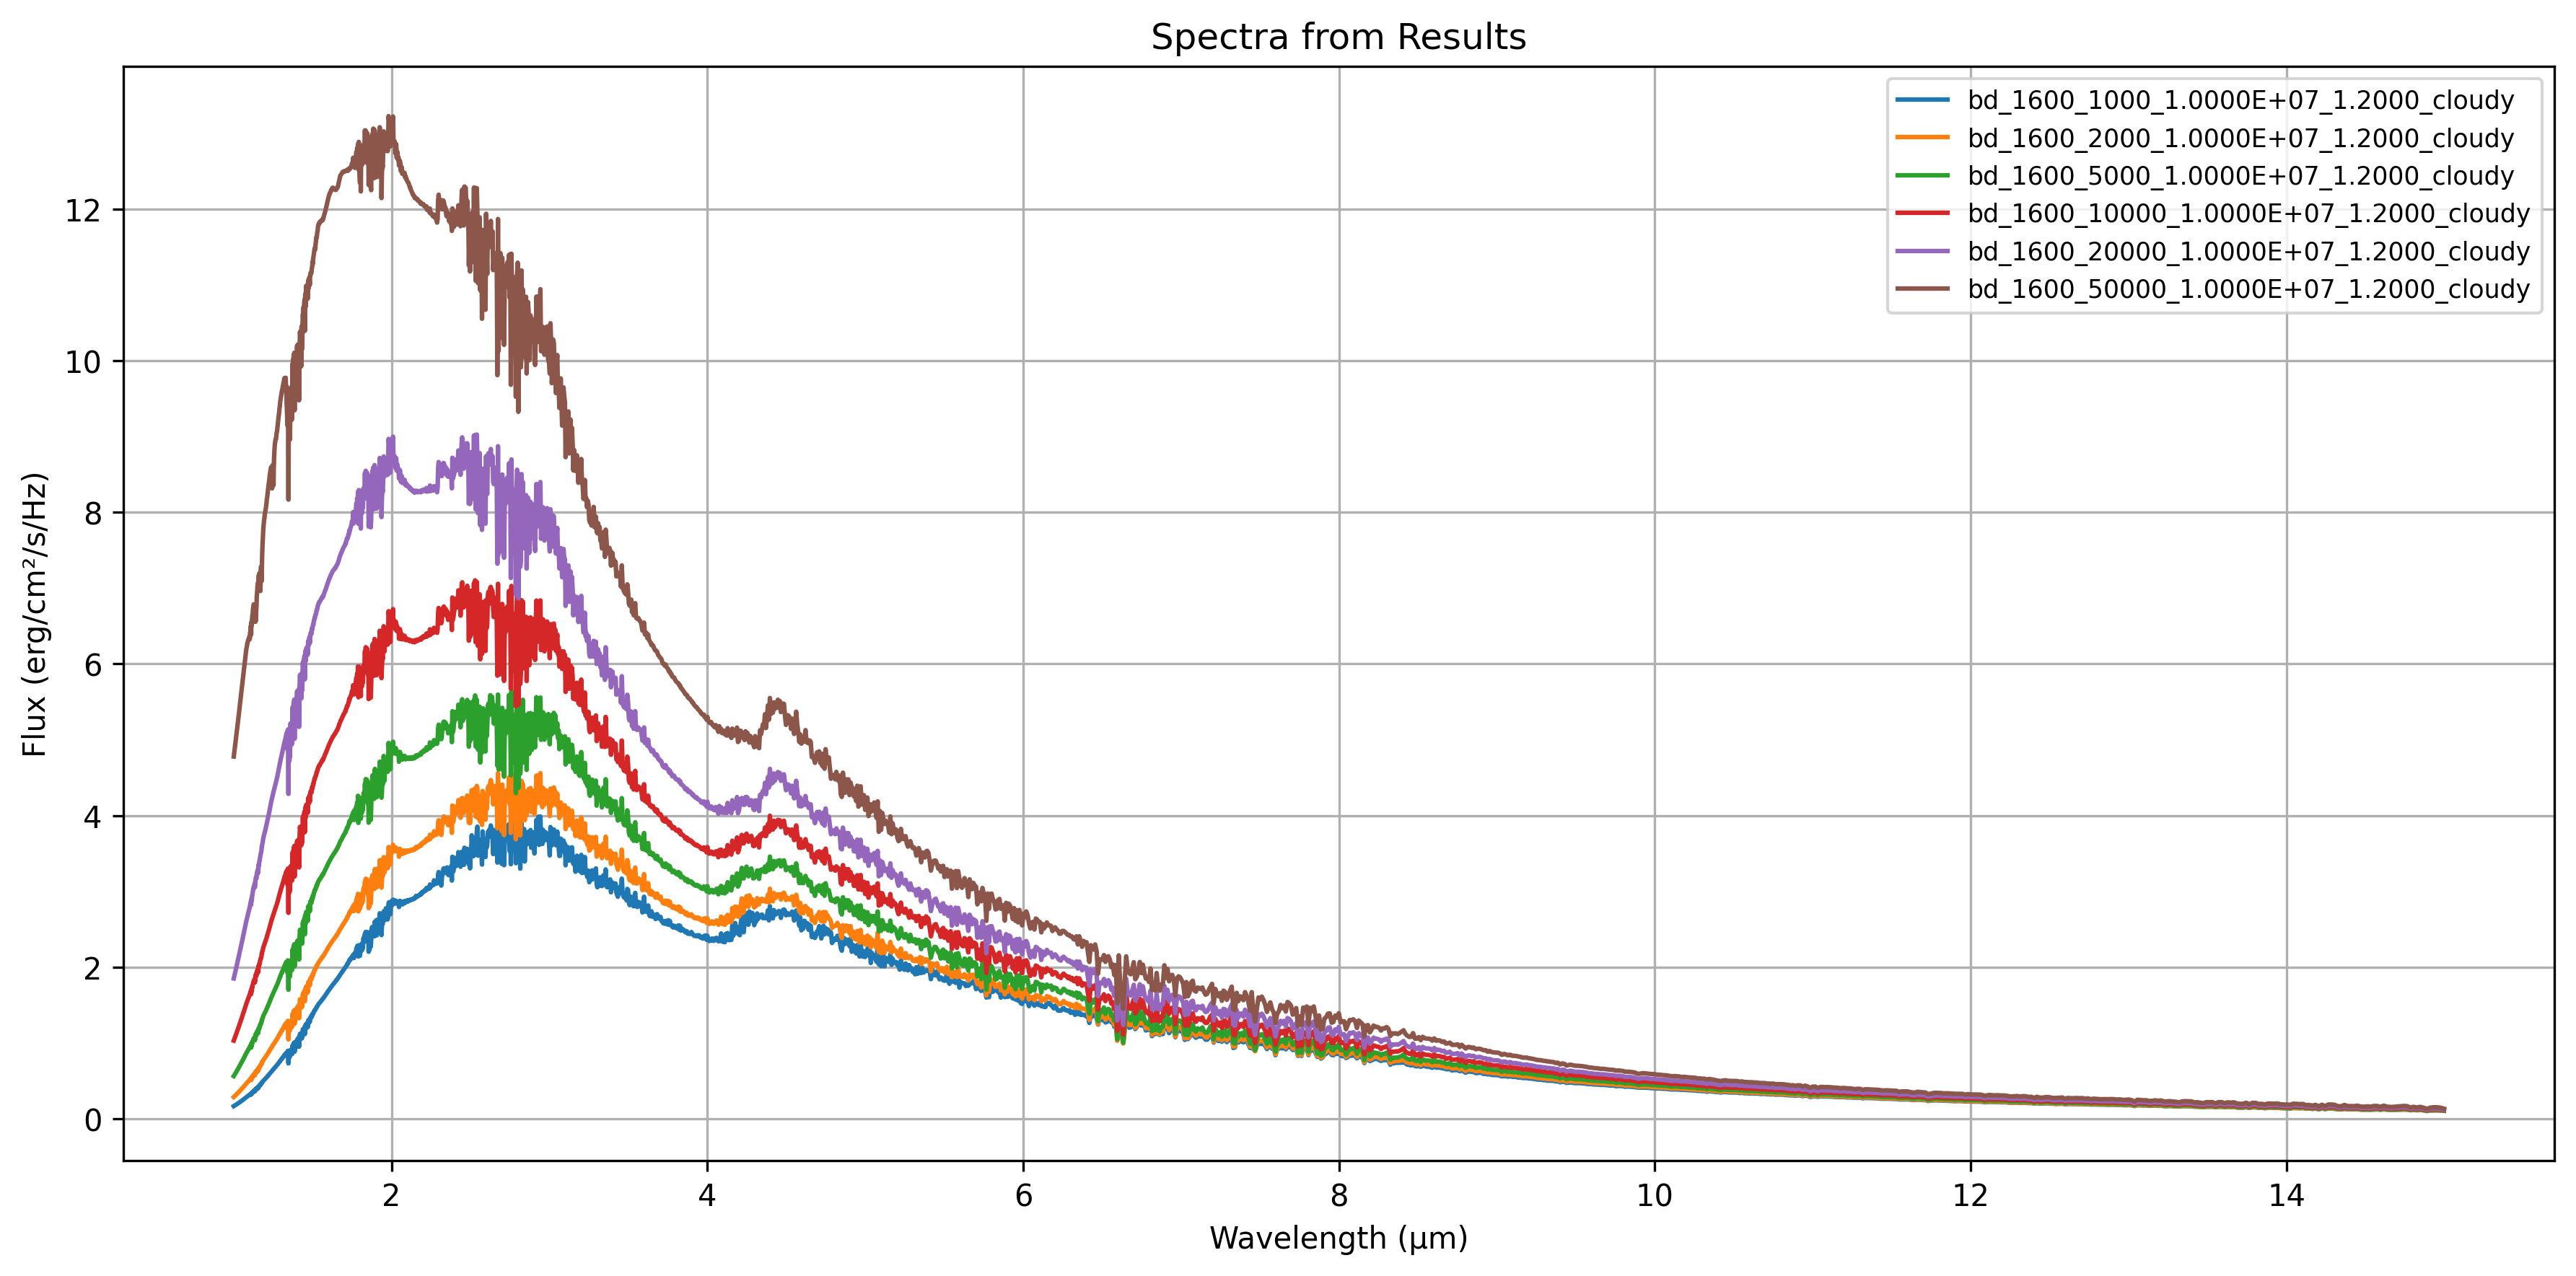

Loading BokehJS ...

Dataset dimensions: Frozen({'pressure': 91, 'wavelength': 40621, 'pressure_layer': 90, 'wavenumber_layer': 196})
Available variables: ['temperature', 'flux_emission', 'e-', 'H2', 'H', 'H+', 'H-', 'H2-', 'H2+', 'H3+', 'He', 'H2O', 'CH4', 'CO', 'NH3', 'N2', 'PH3', 'H2S', 'TiO', 'VO', 'Fe', 'FeH', 'CrH', 'Na', 'K', 'Rb', 'Cs', 'CO2', 'HCN', 'C2H2', 'C2H4', 'C2H6', 'SiO', 'MgH', 'OCS', 'Li', 'LiOH', 'LiH', 'LiCl', 'graphite', 'Al', 'CaH', 'kzz', 'kz', 'opd', 'ssa', 'asy']
Mass and Radius or gravity not provided in xarray, user needs to run gravity function
Model successfully reloaded for new calculations!


In [4]:
import matplotlib.pyplot as plt
import glob
from virga import justplotit as vjpi
from picaso import justplotit as jpi
import xarray 

save_plots = True  # Set to False to skip saving plots

## Plot all spectra from results
plt.figure(figsize=(12, 6), dpi=300)
for model in results:
    model_id = model['model_id']
    x = model['wave']
    y = model['thermal']
    plt.plot(x, y, label=model_id)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Flux (erg/cm²/s/Hz)")
plt.title("Spectra from Results")
# plt.yscale('log')
plt.legend(fontsize='small')
plt.grid()
plt.tight_layout()

savedir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/test/DI_planets_sample'
if save_plots:
    plt.savefig(os.path.join(savedir, f"{runnerName}.pdf"), dpi=300)
plt.show()

# ## Plot virga cloud optics
from bokeh.plotting import show, figure
from bokeh.io import output_notebook 
output_notebook()

# for model in results[:2]:  # Plot first 2 models only
#     virgadf = model['specfile']
#     print(f"\nPlotting model: {model['model_id']}, fsed={model['params']['fsed']}")
#     p = show(vjpi.all_optics(virgadf))

## Load a specific model file, reload and reuse
nc_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.nc')]
model_file = nc_files[0]
ds = xarray.load_dataset(model_file)
print(f"Dataset dimensions: {ds.dims}")
print(f"Available variables: {list(ds.data_vars)}")
opa_reload = jdi.opannection(wave_range=[1, 10])
reuse = jdi.input_xarray(ds, opa_reload, calculation='browndwarf')
## run gravity
gravity_value = os.path.basename(model_file).split('_')[2]
reuse.gravity(gravity=float(gravity_value), gravity_unit=u.Unit('m/(s**2)'))
print("Model successfully reloaded for new calculations!")
sp = reuse.spectrum(opa_reload)
sp = convert_and_regrid(sp, R=500)

p = show(jpi.spectrum(1e4/sp['regridx'], sp['regridy'],
    plot_height=400, plot_width=700, title="Reloaded Spectrum: "+model_file))